# Predictive maintenance using Machine Learning

**Predictive maintenance aims to predict equipment failures before they occur, reducing downtime and maintenance costs**

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

## 2. Load dataset

In [3]:
data = pd.read_csv("predictive_maintenance.csv")
print(data.head())

   UDI Product ID Type  Air temperature [K]  Process temperature [K]  \
0    1     M14860    M                298.1                    308.6   
1    2     L47181    L                298.2                    308.7   
2    3     L47182    L                298.1                    308.5   
3    4     L47183    L                298.2                    308.6   
4    5     L47184    L                298.2                    308.7   

   Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  Target Failure Type  
0                    1551         42.8                0       0   No Failure  
1                    1408         46.3                3       0   No Failure  
2                    1498         49.4                5       0   No Failure  
3                    1433         39.5                7       0   No Failure  
4                    1408         40.0                9       0   No Failure  


## 3. Dataset overview

In [42]:
print(data.columns)
print(data.shape)
print(data.info())
print(data["Failure Type"].unique())
print(data["Target"].unique())
print(data.describe())

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Target', 'Failure Type'],
      dtype='object')
(10000, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Target                   10000 non-null  int64  
 9   Failure Type             10000 non-null  object 
dtypes: float64(3), int

## 4. Exploratory Data Analysis

In [16]:
# Inspecting null values
print("Count of null data:\n",data.isna().sum(), "\n")

#Inspecting number of duplicates
print("Duplicated data:", data.duplicated().sum())

Count of null data:
 UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Target                     0
Failure Type               0
dtype: int64 

Duplicated data: 0


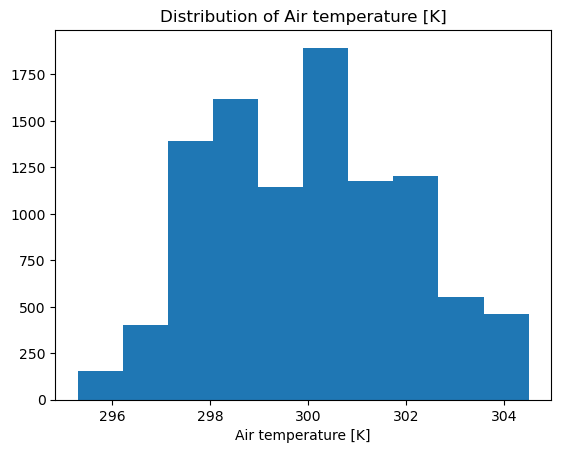

In [19]:
plt.hist(data['Air temperature [K]'])
plt.title("Distribution of Air temperature [K]")
plt.xlabel("Air temperature [K]")
plt.show()

The air temperature follows an approximately normal distribution with no significant skewness. Most observations are concentrated around the mean, suggesting consistent environmental conditions during data collection.

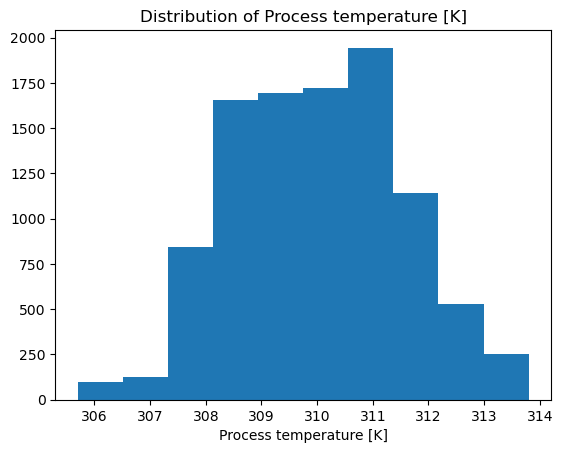

In [20]:
plt.hist(data['Process temperature [K]'])
plt.title("Distribution of Process temperature [K]")
plt.xlabel("Process temperature [K]")
plt.show()

Similar to air temperature, the process temperature appears approximately normally distributed. No unusual peaks or irregular patterns are observed.

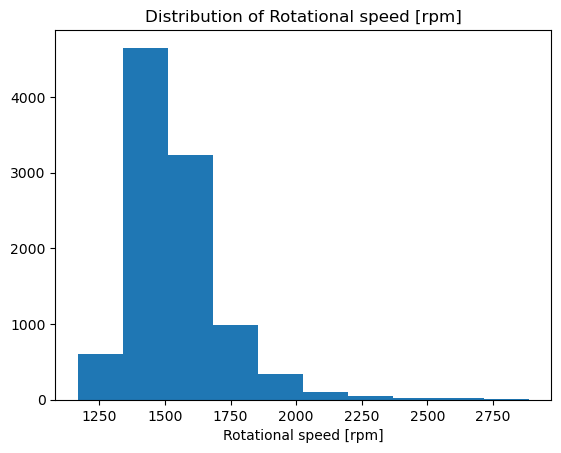

In [21]:
plt.hist(data['Rotational speed [rpm]'])
plt.title("Distribution of Rotational speed [rpm]")
plt.xlabel("Rotational speed [rpm]")
plt.show()

The rotational speed distribution is positively skewed. Most observations are clustered around moderate rotational speeds, while a relatively small number of observations exhibit substantially higher values. Further analysis using boxplots and summary statistics will help determine whether these observations represent true operating conditions or potential outliers.

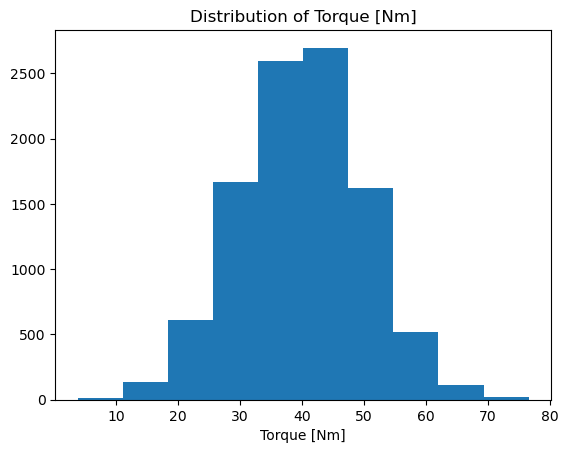

In [22]:
plt.hist(data['Torque [Nm]'])
plt.title("Distribution of Torque [Nm]")
plt.xlabel("Torque [Nm]")
plt.show()

Similar to air and process temperature, the torque appears approximately normally distributed. No unusual peaks or irregular patterns are observed.

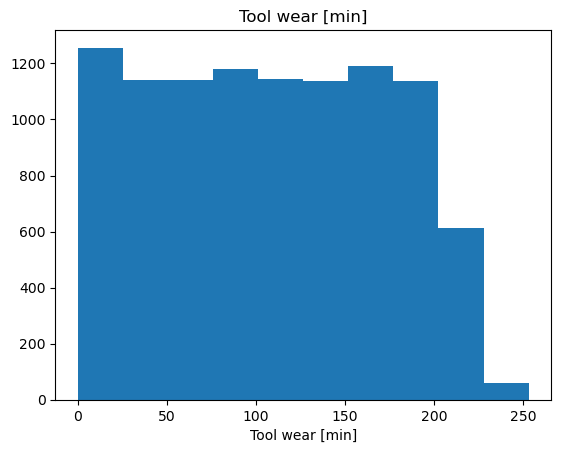

In [25]:
plt.hist(data['Tool wear [min]'])
plt.title("Tool wear [min]")
plt.xlabel("Tool wear [min]")
plt.show()

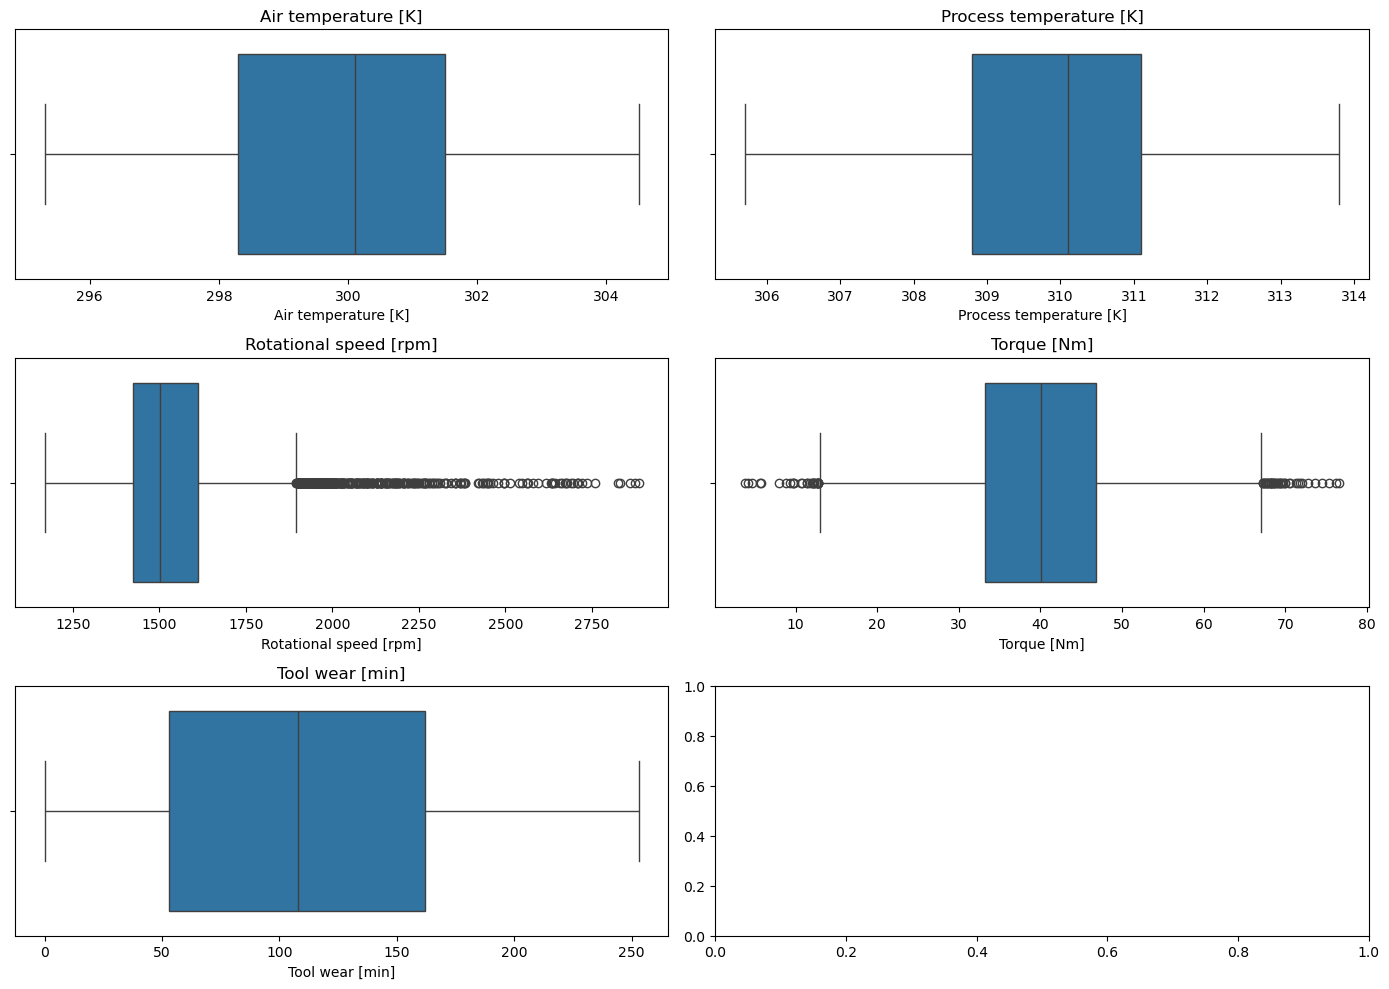

In [31]:
numerical_columns = data.select_dtypes(include="number").columns
numerical_columns = numerical_columns.drop(['UDI', 'Target'])
fig, axes = plt.subplots(3, 2, figsize=(14, 10))

axes = axes.flatten()

for i, column in enumerate(numerical_columns):
    sb.boxplot(
        x=data[column],
        ax=axes[i]
    )

    axes[i].set_title(column)

plt.tight_layout()

In [32]:
Q1 = data["Rotational speed [rpm]"].quantile(0.25)

Q3 = data["Rotational speed [rpm]"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5*IQR

upper = Q3 + 1.5*IQR

In [33]:
outliers = data[
    (data["Rotational speed [rpm]"] < lower) |
    (data["Rotational speed [rpm]"] > upper)
]

In [37]:
print(outliers.head())
print("Number of outliers:", outliers.shape[0])

     UDI Product ID Type  Air temperature [K]  Process temperature [K]  \
14    15     L47194    L                298.6                    309.2   
50    51     L47230    L                298.9                    309.1   
70    71     M14930    M                298.9                    309.0   
101  102     L47281    L                298.8                    308.8   
155  156     H29569    H                298.4                    308.2   

     Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  Target  \
14                     2035         19.6               40       0   
50                     2861          4.6              143       1   
70                     1924         22.6              193       0   
101                    1991         20.7               59       0   
155                    1987         19.8              198       0   

      Failure Type  
14      No Failure  
50   Power Failure  
70      No Failure  
101     No Failure  
155     No Failure  
Number of outl

<Axes: xlabel='Target', ylabel='Rotational speed [rpm]'>

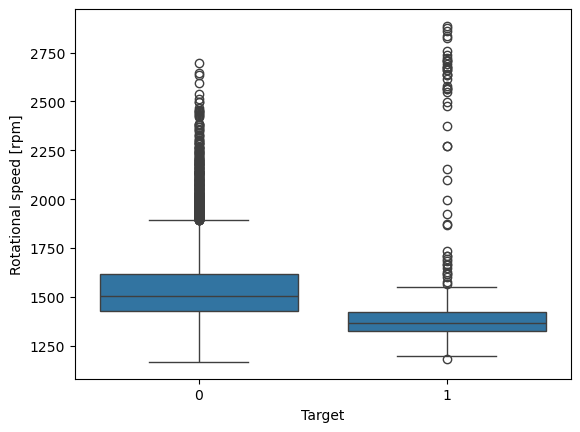

In [41]:
sb.boxplot(
    data=data,
    x="Target",
    y="Rotational speed [rpm]"
)

In [39]:
outliers["Target"].value_counts()

Target
0    383
1     35
Name: count, dtype: int64

In [44]:
data['Type'] = data['Type'].map({'L': 0, 'M': 1, 'H': 2})
print(data.head())

   UDI Product ID  Type  Air temperature [K]  Process temperature [K]  \
0    1     M14860     1                298.1                    308.6   
1    2     L47181     0                298.2                    308.7   
2    3     L47182     0                298.1                    308.5   
3    4     L47183     0                298.2                    308.6   
4    5     L47184     0                298.2                    308.7   

   Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  Target Failure Type  
0                    1551         42.8                0       0   No Failure  
1                    1408         46.3                3       0   No Failure  
2                    1498         49.4                5       0   No Failure  
3                    1433         39.5                7       0   No Failure  
4                    1408         40.0                9       0   No Failure  


In [49]:
data_corr = data.drop(["UDI", "Product ID", "Failure Type"], axis = 1)
print(data_corr.head())

   Type  Air temperature [K]  Process temperature [K]  Rotational speed [rpm]  \
0     1                298.1                    308.6                    1551   
1     0                298.2                    308.7                    1408   
2     0                298.1                    308.5                    1498   
3     0                298.2                    308.6                    1433   
4     0                298.2                    308.7                    1408   

   Torque [Nm]  Tool wear [min]  Target  
0         42.8                0       0  
1         46.3                3       0  
2         49.4                5       0  
3         39.5                7       0  
4         40.0                9       0  


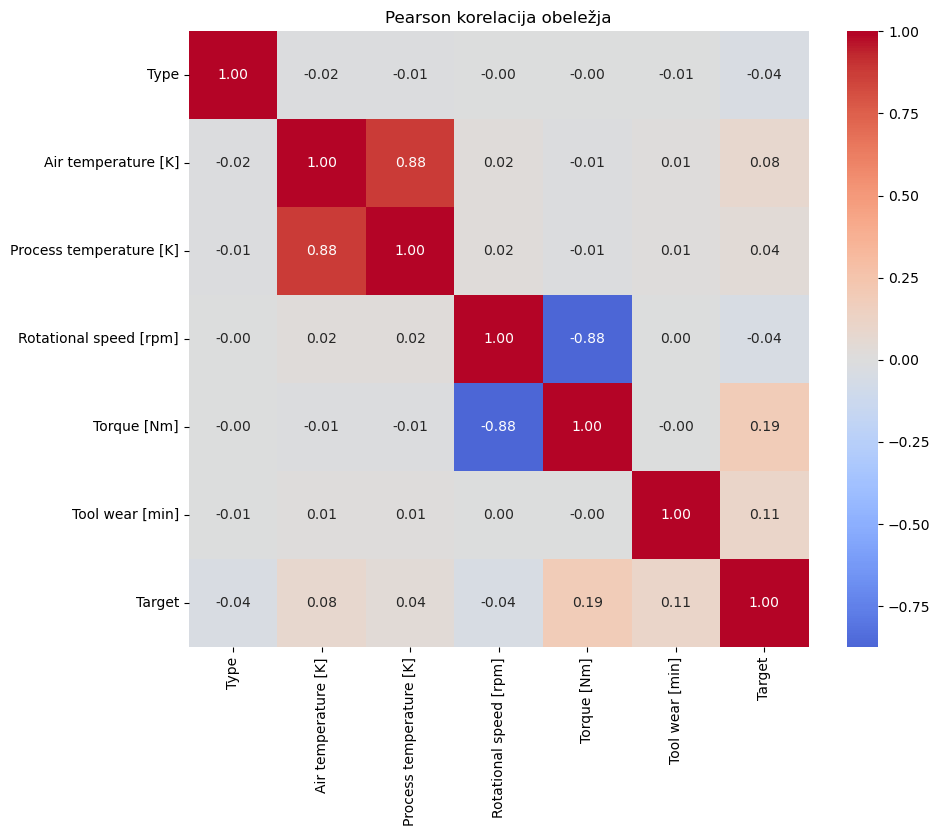

In [50]:
corr_matrix = data_corr.corr(method='pearson')
plt.figure(figsize=(10, 8))
sb.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Pearson korelacija obeležja')
plt.show()

The correlation matrix reveals a strong positive relationship between air temperature and process temperature, which is expected because process temperature is influenced by ambient temperature. A strong relationship is also observed between rotational speed and torque, reflecting the physical characteristics of machine operation.

In [56]:
print(corr_matrix['Target'].sort_values(ascending=False))

Target                     1.000000
Torque [Nm]                0.191321
Tool wear [min]            0.105448
Air temperature [K]        0.082556
Process temperature [K]    0.035946
Type                      -0.036715
Rotational speed [rpm]    -0.044188
Name: Target, dtype: float64


The correlation between individual features and the target variable is generally weak, with torque showing the highest positive correlation (≈0.19). This suggests that machine failure cannot be accurately explained by a single sensor measurement and is likely influenced by the combined interaction of multiple operating conditions.

Since Pearson correlation measures only linear relationships, features with low correlation may still contribute significantly to non-linear machine learning models such as Decision Trees and Random Forests.

### Key Findings from Exploratory Data Analysis

- No missing values or duplicate records were identified.
- Temperature features are approximately normally distributed.
- Rotational speed exhibits positive skewness and several statistical outliers.
- Outliers were retained because the dataset is synthetic and includes Gaussian noise.
- Air temperature and process temperature show strong positive correlation.
- Rotational speed and torque are strongly negative correlated.
- Individual feature correlations with the target are relatively weak, suggesting that machine failure depends on multiple interacting factors rather than a single sensor measurement.

## 5. Data preparing

In [70]:
X = data.drop(['Product ID', 'Target', 'Failure Type'], axis = 1)
y = data.Target

In [71]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

In [73]:
from sklearn.preprocessing import StandardScaler

#Scaled Values for Logistic Regression and KNN
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [74]:
y.value_counts(normalize=True)

Target
0    0.9661
1    0.0339
Name: proportion, dtype: float64

### Logistic regression

In [75]:
lr = LogisticRegression()
lr.fit(X_train_scaled, y_train)
y_pred = lr.predict(X_test_scaled)

#Confusion matrix
test_conf_matrix = pd.DataFrame(
     confusion_matrix(y_test, y_pred),
     index=['actual no', 'actual yes'],
     columns=['predicted no', 'predicted yes']
 )
print(test_conf_matrix)

            predicted no  predicted yes
actual no           1928              4
actual yes            61              7


In [77]:
#Scores
print(accuracy_score(y_test, y_pred))
print(precision_score(y_test, y_pred))
print(recall_score(y_test, y_pred))
print(f1_score(y_test, y_pred))

0.9675
0.6363636363636364
0.10294117647058823
0.17721518987341772


### KNN

In [78]:
classifier = KNeighborsClassifier(n_neighbors = 3)
classifier.fit(X_train_scaled, y_train)
y_pred = classifier.predict(X_test_scaled)
#Confusion matrix
test_conf_matrix = pd.DataFrame(
     confusion_matrix(y_test, y_pred),
     index=['actual no', 'actual yes'],
     columns=['predicted no', 'predicted yes']
 )
print(test_conf_matrix)

            predicted no  predicted yes
actual no           1922             10
actual yes            47             21


In [79]:
#Scores
print(accuracy_score(y_test, y_pred))
print(precision_score(y_test, y_pred))
print(recall_score(y_test, y_pred))
print(f1_score(y_test, y_pred))

0.9715
0.6774193548387096
0.3088235294117647
0.42424242424242425


### Desicion Tree

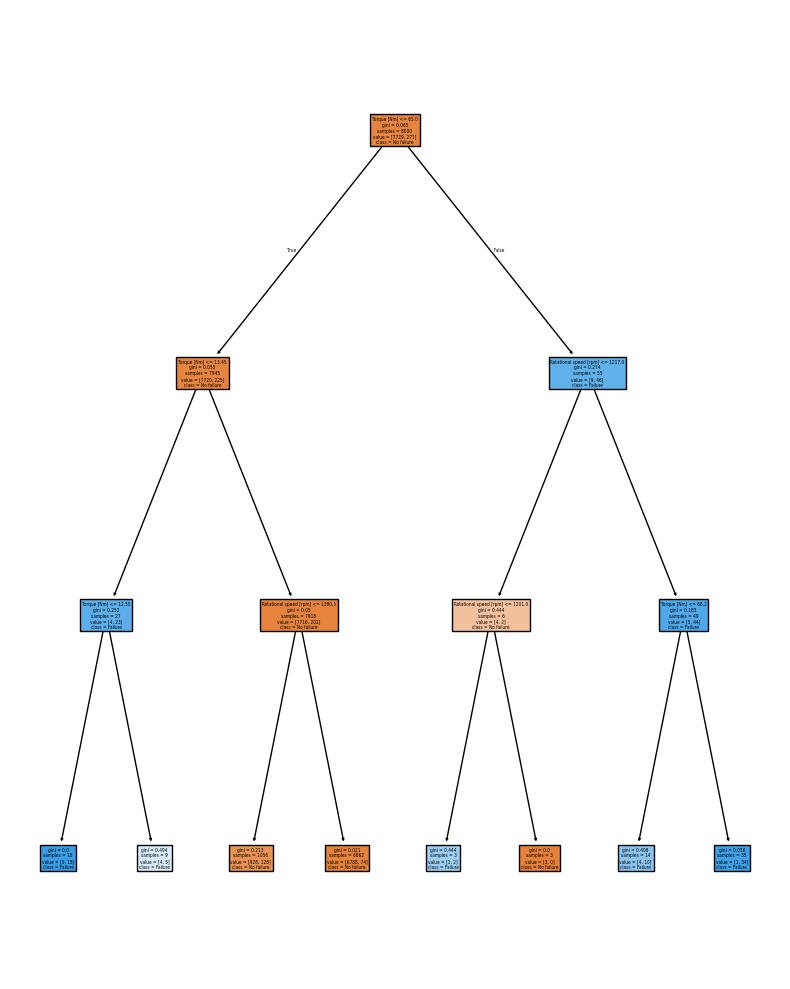

In [86]:
dt = DecisionTreeClassifier(max_depth=3, criterion='gini')
dt.fit(X_train, y_train)
y_pred = dt.predict(X_test)
from sklearn import tree

plt.figure(figsize=(8,10))
tree.plot_tree(dt, feature_names = X_train.columns, class_names = ['No failure','Failure'], filled=True)
plt.tight_layout()
plt.show()

In [87]:
#Scores
print(accuracy_score(y_test, y_pred))
print(precision_score(y_test, y_pred))
print(recall_score(y_test, y_pred))
print(f1_score(y_test, y_pred))

0.966
0.0
0.0
0.0


C:\Users\salip\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
